In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
data = {
    "Area": [800, 1000, 1200, 1400, 1600, 1800, 2000, 2200, 2400, 2600,
             900, 1100, 1300, 1500, 1700, 1900, 2100, 2300, 2500, 2700,
             850, 1050, 1250, 1450, 1650, 1850, 2050, 2250, 2450, 2650],

    "Bedrooms": [2, 2, 3, 3, 3, 4, 4, 4, 5, 5,
                 2, 3, 3, 3, 4, 4, 4, 5, 5, 5,
                 2, 2, 3, 3, 4, 4, 4, 5, 5, 5],

    "Bathrooms": [1, 2, 2, 2, 3, 3, 3, 4, 4, 4,
                  1, 2, 2, 3, 3, 3, 4, 4, 4, 5,
                  1, 2, 2, 2, 3, 3, 3, 4, 4, 5],

    "Age": [20, 18, 15, 12, 10, 8, 7, 5, 4, 3,
            22, 19, 16, 14, 11, 9, 7, 6, 4, 2,
            25, 20, 17, 13, 10, 8, 6, 5, 3, 1],

    "Location_Score": [5, 6, 6, 7, 7, 8, 8, 9, 9, 10,
                       5, 6, 7, 7, 8, 8, 9, 9, 10, 10,
                       5, 6, 6, 7, 8, 8, 9, 9, 10, 10],

    "Price": [42, 55, 68, 78, 92, 105, 120, 138, 155, 175,
              48, 62, 72, 85, 98, 112, 130, 148, 165, 185,
              45, 58, 70, 82, 95, 108, 125, 142, 160, 180]
}

df = pd.DataFrame(data)
print("House Price Dataset Created Successfully!")
print("Dataset Shape:", df.shape)
df.head()

House Price Dataset Created Successfully!
Dataset Shape: (30, 6)


,Area,Bedrooms,Bathrooms,Age,Location_Score,Price
0,800,2,1,20,5,42
1,1000,2,2,18,6,55
2,1200,3,2,15,6,68
3,1400,3,2,12,7,78
4,1600,3,3,10,7,92


In [4]:
print("Dataset Information:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Area            30 non-null     int64
 1   Bedrooms        30 non-null     int64
 2   Bathrooms       30 non-null     int64
 3   Age             30 non-null     int64
 4   Location_Score  30 non-null     int64
 5   Price           30 non-null     int64
dtypes: int64(6)
memory usage: 1.5 KB
None

Missing Values:
Area              0
Bedrooms          0
Bathrooms         0
Age               0
Location_Score    0
Price             0
dtype: int64


In [5]:
print("First 10 Records:")
display(df.head(10))

First 10 Records:


,Area,Bedrooms,Bathrooms,Age,Location_Score,Price
0,800,2,1,20,5,42
1,1000,2,2,18,6,55
2,1200,3,2,15,6,68
3,1400,3,2,12,7,78
4,1600,3,3,10,7,92
5,1800,4,3,8,8,105
6,2000,4,3,7,8,120
7,2200,4,4,5,9,138
8,2400,5,4,4,9,155
9,2600,5,4,3,10,175


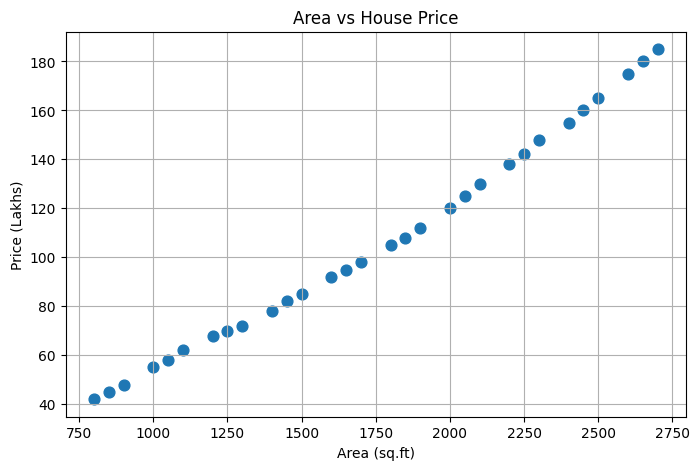

In [6]:
plt.figure(figsize=(8,5))
plt.scatter(df["Area"], df["Price"], s=60)
plt.xlabel("Area (sq.ft)")
plt.ylabel("Price (Lakhs)")
plt.title("Area vs House Price")
plt.grid(True)
plt.show()

In [7]:
X = df[["Area", "Bedrooms", "Bathrooms", "Age", "Location_Score"]]
y = df["Price"]
print("Input Features:")
print(X.head())
print("\nTarget:")
print(y.head())

Input Features:
   Area  Bedrooms  Bathrooms  Age  Location_Score
0   800         2          1   20               5
1  1000         2          2   18               6
2  1200         3          2   15               6
3  1400         3          2   12               7
4  1600         3          3   10               7

Target:
0    42
1    55
2    68
3    78
4    92
Name: Price, dtype: int64


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (24, 5)
Testing Data: (6, 5)


In [9]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)
print("Linear Regression Model Training Completed!")

Linear Regression Model Training Completed!


In [10]:
tree_model = DecisionTreeRegressor(random_state=42)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

print("Decision Tree Regression Model Training Completed!")

Decision Tree Regression Model Training Completed!


In [11]:
forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

forest_model.fit(X_train, y_train)

forest_pred = forest_model.predict(X_test)

print("Random Forest Regression Model Training Completed!")

Random Forest Regression Model Training Completed!


In [12]:
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_mse = mean_squared_error(y_test, linear_pred)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression Performance")
print("--------------------------------")
print("Mean Absolute Error:", linear_mae)
print("Mean Squared Error:", linear_mse)
print("Root Mean Squared Error:", linear_rmse)
print("R2 Score:", linear_r2)
print("R2 Accuracy:", linear_r2 * 100, "%")

Linear Regression Performance
--------------------------------
Mean Absolute Error: 2.3324995529564774
Mean Squared Error: 8.701347976957685
Root Mean Squared Error: 2.949804735394817
R2 Score: 0.9905987836983651
R2 Accuracy: 99.05987836983651 %


In [13]:
tree_mae = mean_absolute_error(y_test, tree_pred)
tree_mse = mean_squared_error(y_test, tree_pred)
tree_rmse = np.sqrt(tree_mse)
tree_r2 = r2_score(y_test, tree_pred)

print("Decision Tree Regression Performance")
print("-------------------------------------")
print("Mean Absolute Error:", tree_mae)
print("Mean Squared Error:", tree_mse)
print("Root Mean Squared Error:", tree_rmse)
print("R2 Score:", tree_r2)
print("R2 Accuracy:", tree_r2 * 100, "%")

Decision Tree Regression Performance
-------------------------------------
Mean Absolute Error: 8.0
Mean Squared Error: 91.66666666666667
Root Mean Squared Error: 9.574271077563381
R2 Score: 0.9009603841536614
R2 Accuracy: 90.09603841536614 %


In [14]:
forest_mae = mean_absolute_error(y_test, forest_pred)
forest_mse = mean_squared_error(y_test, forest_pred)
forest_rmse = np.sqrt(forest_mse)
forest_r2 = r2_score(y_test, forest_pred)

print("Random Forest Regression Performance")
print("-------------------------------------")
print("Mean Absolute Error:", forest_mae)
print("Mean Squared Error:", forest_mse)
print("Root Mean Squared Error:", forest_rmse)
print("R2 Score:", forest_r2)
print("R2 Accuracy:", forest_r2 * 100, "%")

Random Forest Regression Performance
-------------------------------------
Mean Absolute Error: 4.06333333333333
Mean Squared Error: 21.374066666666646
Root Mean Squared Error: 4.623209563351703
R2 Score: 0.9769067707082834
R2 Accuracy: 97.69067707082833 %


In [15]:
results = pd.DataFrame({
    "Algorithm": [
        "Linear Regression",
        "Decision Tree Regression",
        "Random Forest Regression"
    ],
    "MAE": [
        linear_mae,
        tree_mae,
        forest_mae
    ],
    "RMSE": [
        linear_rmse,
        tree_rmse,
        forest_rmse
    ],
    "R2 Score": [
        linear_r2,
        tree_r2,
        forest_r2
    ]
})
print("Regression Algorithm Comparison:")
display(results)

Regression Algorithm Comparison:


,Algorithm,MAE,RMSE,R2 Score
0,Linear Regression,2.332500,2.949805,0.990599
1,Decision Tree Regression,8.000000,9.574271,0.900960
2,Random Forest Regression,4.063333,4.623210,0.976907


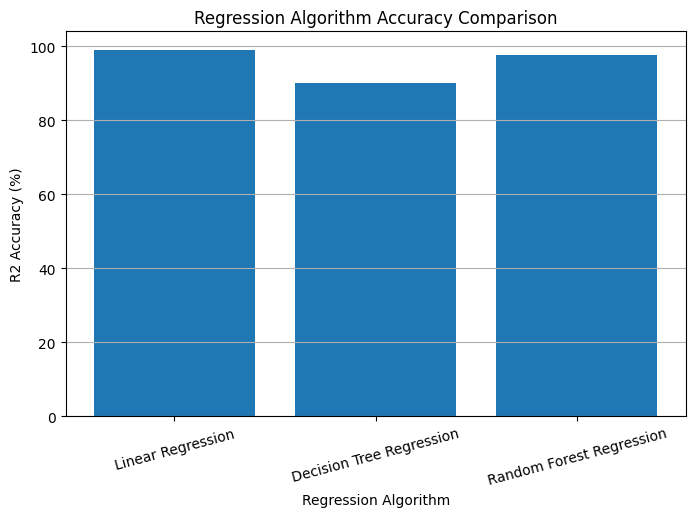

In [16]:
plt.figure(figsize=(8,5))

plt.bar(
    results["Algorithm"],
    results["R2 Score"] * 100
)

plt.xlabel("Regression Algorithm")
plt.ylabel("R2 Accuracy (%)")
plt.title("Regression Algorithm Accuracy Comparison")

plt.xticks(rotation=15)
plt.grid(axis="y")

plt.show()

In [17]:
print("Actual Prices:")
print(y_test.values)

print("\nPredicted Prices:")
print(forest_pred)

Actual Prices:
[142 112  82 148 155 175]

Predicted Prices:
[144.17 107.13  78.55 141.8  155.69 168.  ]


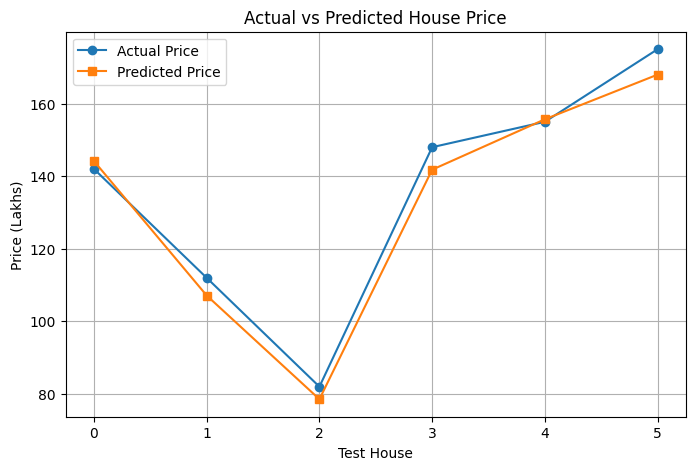

In [18]:
plt.figure(figsize=(8,5))
plt.plot(
    range(len(y_test)),
    y_test.values,
    marker='o',
    label="Actual Price"
)
plt.plot(
    range(len(forest_pred)),
    forest_pred,
    marker='s',
    label="Predicted Price"
)
plt.xlabel("Test House")
plt.ylabel("Price (Lakhs)")
plt.title("Actual vs Predicted House Price")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
new_house = pd.DataFrame({
    "Area": [2000],
    "Bedrooms": [4],
    "Bathrooms": [3],
    "Age": [5],
    "Location_Score": [8]
})

prediction = forest_model.predict(new_house)

print("House Price Prediction")
print("----------------------")

print("Area:", new_house["Area"].iloc[0], "sq.ft")
print("Bedrooms:", new_house["Bedrooms"].iloc[0])
print("Bathrooms:", new_house["Bathrooms"].iloc[0])
print("Age:", new_house["Age"].iloc[0], "years")
print("Location Score:", new_house["Location_Score"].iloc[0])

print("Predicted House Price:",
      round(prediction[0], 2), "Lakhs")

House Price Prediction
----------------------
Area: 2000 sq.ft
Bedrooms: 4
Bathrooms: 3
Age: 5 years
Location Score: 8
Predicted House Price: 125.45 Lakhs


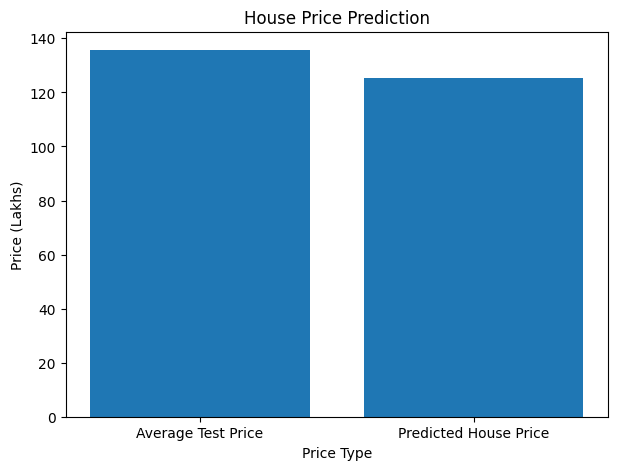

In [20]:
plt.figure(figsize=(7,5))

plt.bar(
    ["Average Test Price", "Predicted House Price"],
    [y_test.mean(), prediction[0]]
)

plt.xlabel("Price Type")
plt.ylabel("Price (Lakhs)")
plt.title("House Price Prediction")

plt.show()